# Describing Membranes As Meshes

## Overview

### Questions

* What is the Triangulated Mesh Model?
* How can I create a mesh modeling a flat surface?
* How can I create a mesh modeling a sphere?

### Objectives

- Introducing the Triangulated Mesh Model.
- Create a triangulation of the xy-plane.
- Create a triangulation of a sphere surface.
## Boilerplate Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull  
import pyvista as pv

## Triangulated Mesh Model
Modeling membranes and other deformable interfaces as triangulated meshes is a common coarse-grained approach in molecular simulations, particularly for studying lipid bilayers and biological membranes at macroscopic scales.
The **triangulated mesh model** represents the interface surface as a set of vertices connected by edges forming a mesh of triangles.
Each vertex represents a coarse-grained membrane patch (e.g., a group of lipids).
This approach allows users to integrate membranes with specific elasticities and interactions with other particles.

![Triangulation](triangulation.svg)

## Creating a triangulation of the xy-plane.
To create a triangulation of the xy-plane the positions of the vertices have to defined first.

In [2]:
# box size
L = 10

# Number of vertices per row
row = 10

# Number of vertices
N = row*row

# Create meshgrid for a rectangular pattern
x = np.arange(-L/2, L/2, L/row)
y = np.arange(-L/2, L/2, L/row)*np.sqrt(3)/2
X, Y = np.meshgrid(x, y)

# Offset every second row to create a triangular pattern
X[1::2, :] += 0.5

# Combine X and Y coordinates to define vertex positions
vertex_positions = np.column_stack([X.flatten(), Y.flatten(), np.zeros(N)])

vertex_positions

array([[-5.        , -4.33012702,  0.        ],
       [-4.        , -4.33012702,  0.        ],
       [-3.        , -4.33012702,  0.        ],
       [-2.        , -4.33012702,  0.        ],
       [-1.        , -4.33012702,  0.        ],
       [ 0.        , -4.33012702,  0.        ],
       [ 1.        , -4.33012702,  0.        ],
       [ 2.        , -4.33012702,  0.        ],
       [ 3.        , -4.33012702,  0.        ],
       [ 4.        , -4.33012702,  0.        ],
       [-4.5       , -3.46410162,  0.        ],
       [-3.5       , -3.46410162,  0.        ],
       [-2.5       , -3.46410162,  0.        ],
       [-1.5       , -3.46410162,  0.        ],
       [-0.5       , -3.46410162,  0.        ],
       [ 0.5       , -3.46410162,  0.        ],
       [ 1.5       , -3.46410162,  0.        ],
       [ 2.5       , -3.46410162,  0.        ],
       [ 3.5       , -3.46410162,  0.        ],
       [ 4.5       , -3.46410162,  0.        ],
       [-5.        , -2.59807621,  0.   

In adition to the vertex positions also the triangulation data is needed.
The mesh information is given by an array of triplets which define each triangle in the mesh and consist of the vertex indices.

In [3]:
# Create array of vertex indices
v_index = np.arange(N)

# Find index of vertex to the right in same row
vr_index = v_index+1

# Consider periodic boundaries
vr_index[row-1::row] -=row

# Find index of vertex above and below the edge between idx1 and idx2
e_index = np.repeat(v_index,2).reshape(-1,2)

# Find index of vertex above the edge between v_index and vr_index
e_index[:,0]+=row
# Find index of vertex below the edge between v_index and vr_index
e_index[:,1]-=row

# Consider periodic boundaries
e_index = e_index.reshape(row,-1,2)
# periodic boundaries in x direction
e_index[1::2] += 1
# periodic boundaries in y direction
e_index[1::2,-1] -= row
e_index = e_index.reshape(-1)%N

# Create dublicates of the vertices to create triangle above and below each edge
v_index = np.repeat(v_index,2)
vr_index = np.repeat(vr_index,2)

# Switch vr_index and e_index for triangle below each edge to make mesh orientable
vr_index[1::2]=e_index[1::2]
e_index[1::2]=vr_index[0::2]

# Create all triangles making up the mesh
triangles = np.column_stack([v_index,vr_index,e_index])

print(triangles)

[[ 0  1 10]
 [ 0 90  1]
 [ 1  2 11]
 [ 1 91  2]
 [ 2  3 12]
 [ 2 92  3]
 [ 3  4 13]
 [ 3 93  4]
 [ 4  5 14]
 [ 4 94  5]
 [ 5  6 15]
 [ 5 95  6]
 [ 6  7 16]
 [ 6 96  7]
 [ 7  8 17]
 [ 7 97  8]
 [ 8  9 18]
 [ 8 98  9]
 [ 9  0 19]
 [ 9 99  0]
 [10 11 21]
 [10  1 11]
 [11 12 22]
 [11  2 12]
 [12 13 23]
 [12  3 13]
 [13 14 24]
 [13  4 14]
 [14 15 25]
 [14  5 15]
 [15 16 26]
 [15  6 16]
 [16 17 27]
 [16  7 17]
 [17 18 28]
 [17  8 18]
 [18 19 29]
 [18  9 19]
 [19 10 20]
 [19  0 10]
 [20 21 30]
 [20 10 21]
 [21 22 31]
 [21 11 22]
 [22 23 32]
 [22 12 23]
 [23 24 33]
 [23 13 24]
 [24 25 34]
 [24 14 25]
 [25 26 35]
 [25 15 26]
 [26 27 36]
 [26 16 27]
 [27 28 37]
 [27 17 28]
 [28 29 38]
 [28 18 29]
 [29 20 39]
 [29 19 20]
 [30 31 41]
 [30 21 31]
 [31 32 42]
 [31 22 32]
 [32 33 43]
 [32 23 33]
 [33 34 44]
 [33 24 34]
 [34 35 45]
 [34 25 35]
 [35 36 46]
 [35 26 36]
 [36 37 47]
 [36 27 37]
 [37 38 48]
 [37 28 38]
 [38 39 49]
 [38 29 39]
 [39 30 40]
 [39 20 30]
 [40 41 50]
 [40 30 41]
 [41 42 51]
 [41

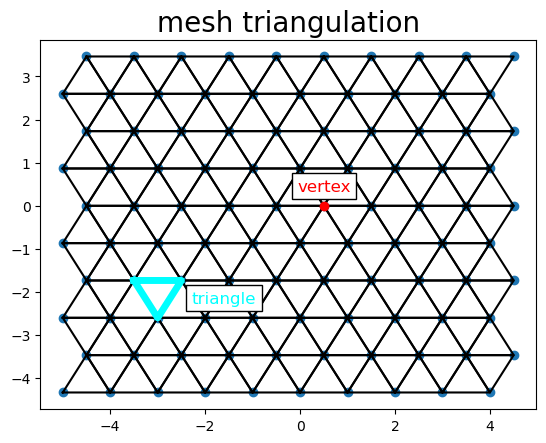

In [5]:
# Create all triangles making up the mesh
triangles_vis = np.column_stack([v_index,vr_index,e_index,v_index])

plt.scatter(vertex_positions[:,0],vertex_positions[:,1])

for tr_pos in vertex_positions[triangles_vis[:18:2]]:
    plt.plot(tr_pos[:,0],tr_pos[:,1],color="black")

for i in range(1,9):
    for tr_pos in vertex_positions[triangles_vis[i*20:(i+1)*20-2]]:
        plt.plot(tr_pos[:,0],tr_pos[:,1],color="black")

for tr_pos in vertex_positions[triangles_vis[181:199:2]]:
    plt.plot(tr_pos[:,0],tr_pos[:,1],color="black")
    
plt.text(0.5, 0.45, "vertex", fontsize=12, bbox=dict(facecolor='white'), color="red", ha="center", va="center")
plt.scatter(0.5, 0,color="red",zorder=10)

for tr_pos in vertex_positions[triangles_vis[63:64]]:
    plt.plot(tr_pos[:,0],tr_pos[:,1],color="cyan",lw=5)
    
plt.text(-1.6, -2.15, "triangle", fontsize=12, bbox=dict(facecolor='white'), color="cyan", ha="center", va="center")

plt.title("mesh triangulation", fontsize=20, color="black")


plt.savefig("2D_triangulation.png")

## Creating a triangulation of a sphere surface.

First, we distribute vertices on a sphere using the fibancci algorithm (https://doi.org/10.1007/s11004-009-9257-x)

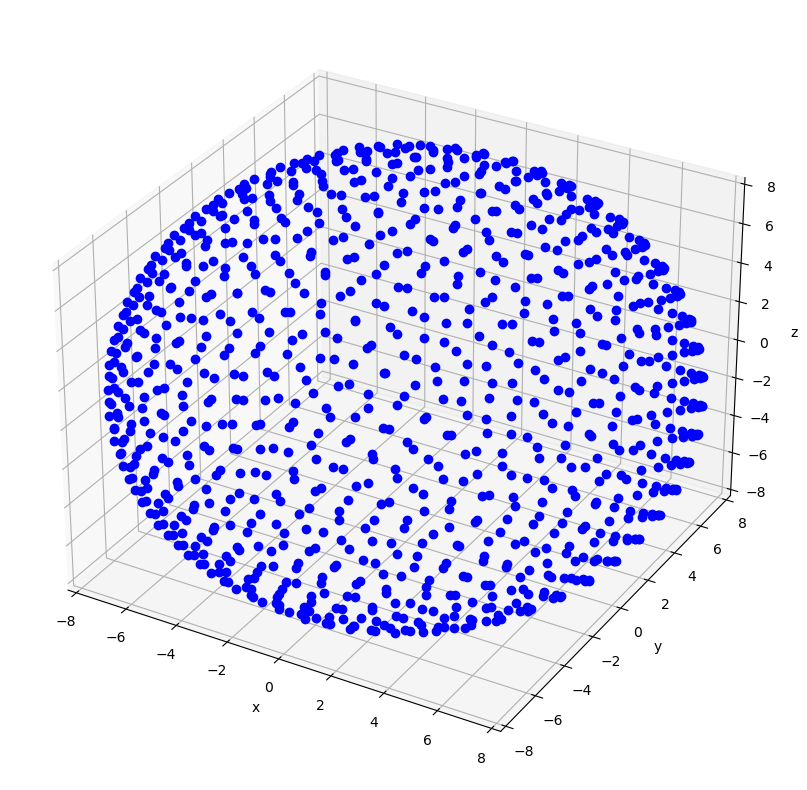

In [6]:
# Number of points on the sphere
num_pts = 1000

# Radius of the sphere
R = 10

#Fibancci algorithm
indices = np.arange(0, num_pts, dtype=float) + 0.5

phi = np.arccos(1 - 2*indices/num_pts)
theta = np.pi * (1 + 5**0.5) * indices

x, y, z = R * np.cos(theta) * np.sin(phi), R * np.sin(theta) * np.sin(phi), R * np.cos(phi)

vertex_positions = np.column_stack((x,y,z))

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x,y,z,'bo') 

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.set_xlim3d(-8,8)
ax.set_ylim3d(-8,8)
ax.set_zlim3d(-8,8)

plt.show()


We determine the triangles of the mesh by computing the convex hull on the vertex positions

In [7]:
hull=ConvexHull(vertex_positions)

triangles = hull.simplices

# calculate normal of each triangle and orient mesh so all triangle normals point away from center position
for i in range(len(triangles)):
    normal = np.cross(vertex_positions[triangles[i,0]]-vertex_positions[triangles[i,2]],vertex_positions[triangles[i,0]]-vertex_positions[triangles[i,1]])
    if np.dot(vertex_positions[triangles[i,0]],normal) < 0:
        triangles[i,1],triangles[i,2] = triangles[i,2],triangles[i,1]

print(triangles)

[[459 493 438]
 [404 459 438]
 [178 144 199]
 ...
 [703 648 669]
 [703 682 648]
 [703 737 682]]


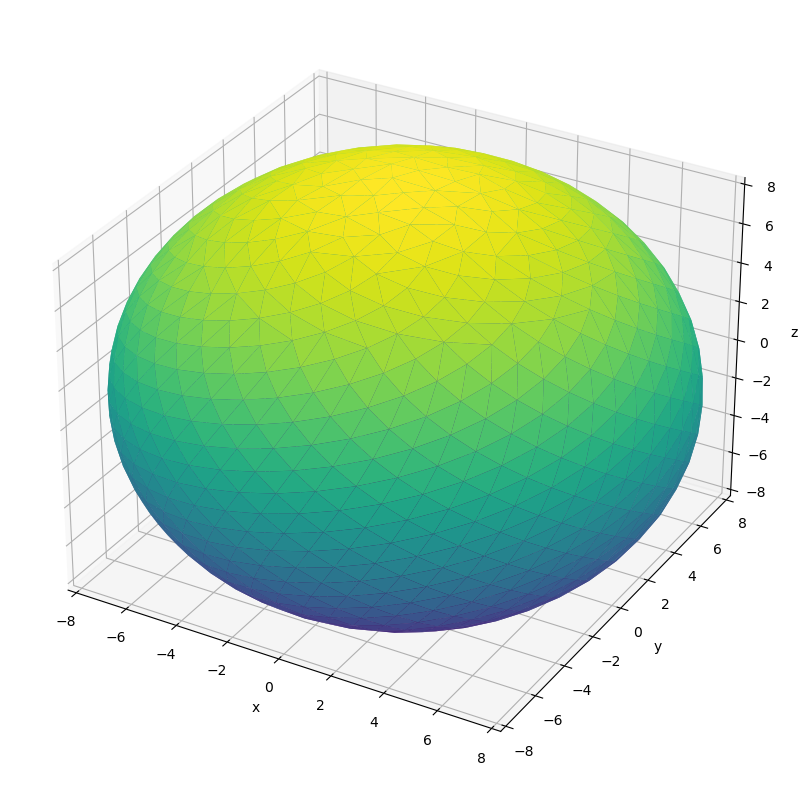

In [8]:
# Visualize the sphere mesh 
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

ax.plot_trisurf(x, y, z, triangles=hull.simplices,
                cmap="viridis",linewidths=3);


ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.set_xlim3d(-8,8)
ax.set_ylim3d(-8,8)
ax.set_zlim3d(-8,8)

plt.savefig("2D_triangulation.png")

/usr/local/Caskroom/miniconda/base/envs/hoomd-env/lib/python3.10/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


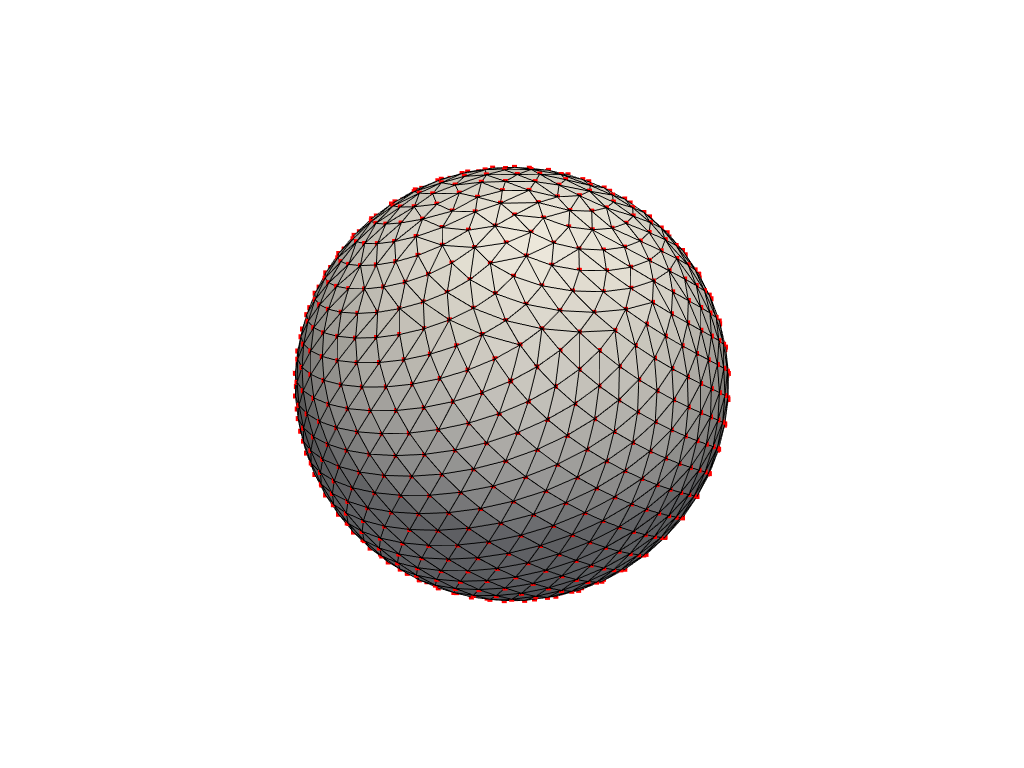

libpng warning: Application built with libpng-1.4.12 but running with 1.6.39


In [10]:
mesh = pv.PolyData(vertex_positions)

# Delaunay triangulation and surface extraction:
triangulated = mesh.delaunay_3d()
surface = triangulated.extract_geometry()

plotter = pv.Plotter()
plotter.add_mesh(surface, color='white', show_edges=True)
plotter.add_points(vertex_positions, color='red', point_size=5)
plotter.show()

plotter.save_graphic("sphere_triangulation.svg")  